# Velocity bins of the broad Hβ profile — velocity-resolved lags

Interactive verification twin of `velocity_bins.py` — **keep the two in
sync** (the function cell below is a verbatim copy of the CLI's core block).

Input: rms spectrum (`spec_rms_<line>.txt`) or narrow-subtracted mean
spectrum (`spec_mean_<line>.txt.subnarrow`), rest-frame, columns
`wave flux [err]`.

Method (Denney et al. 2009, ApJ 704, L80; MAHA I §4.4 + App. B):
* profile $P(\lambda)$ = flux above a linear continuum between two line-free windows
* **zero velocity** = flux centroid of the `narrow_hb` column of
  `<obj>_narrow_profile.txt` (from `subtract_narrow_mean`), $v = c(\lambda-\lambda_0)/\lambda_0$
* **equal-flux bins**: interior edges = first crossings of the cumulative flux
  through $k/N$ of the net window flux (raw pixels kept — negative noise dips
  contribute flux but the first-crossing rule keeps edges deterministic;
  multi-crossing edges are flagged)
* **equal-width bins**: uniform edges in velocity over the same window
* **number of bins** (rule of thumb agreed 2026-07-19):
  default $N = \lfloor \Delta v_{\rm window} / {\rm LSF} \rfloor$ (MAHA LSF: 925 km/s);
  any bin narrower than the LSF triggers a **warning** — such bins are not
  kinematically independent of their neighbours

In [2]:
# ---------------- config: EDIT HERE ----------------
SPEC = 'spec_rms_hbeta.txt'                     # rms or mean .subnarrow, rest-frame
NARROW_PROFILE = 'NGC3227_narrow_profile.txt'   # v=0 from its narrow_hb column
V0_WAVE = None                  # alternative: give the zero-velocity wavelength
                                # directly (A); then NARROW_PROFILE is ignored

LINE_WIN = (4800.0, 4950.0)     # Hbeta integration window = outer boundaries
CONTI_LEFT = (4780.0, 4800.0)   # line-free continuum windows;
CONTI_RIGHT = (4950.0, 4970.0)  # set both to None -> continuum = 0
NBINS = None                    # None = default floor(window / LSF)
LSF_KMS = 925.0                 # instrumental broadening FWHM (MAHA: 925)
OBJ = 'NGC3227'                 # output name tag
TAG = None                      # None = guess rms/mean from the file name

P = {'line_win': LINE_WIN, 'conti_left': CONTI_LEFT,
     'conti_right': CONTI_RIGHT}

In [3]:
# ---------------- shared core (verbatim from velocity_bins.py) ----------------
import numpy as np

UNIT = 1.0e-14
C_KMS = 299792.458

# Okabe-Ito colorblind-safe palette, fixed assignment
C_DATA = '#000000'       # observed spectrum
C_MODEL = '#E69F00'      # bin edges
C_BROAD = '#0072B2'      # equal-flux scheme
C_NARROW = '#009E73'     # zero-velocity line
C_SUB = '#D55E00'        # line profile P
C_CON = '#CC79A7'        # continuum / background lines


def read_spec(filename):
    data = np.loadtxt(filename)
    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError('need at least 2 columns: wave flux [err]')
    err = data[:, 2] if data.shape[1] > 2 else np.zeros(data.shape[0])
    return data[:, 0], data[:, 1], err


def window_median(wave, flux, lim1, lim2):
    """Median flux and mean wavelength inside [lim1, lim2]."""
    idx = np.where((wave >= lim1) & (wave <= lim2))[0]
    if idx.size == 0:
        raise ValueError('empty window %.1f-%.1f' % (lim1, lim2))
    return np.median(flux[idx]), np.mean(wave[idx])


def linear_through(w1, f1, w2, f2, wave):
    return f1 + (f2 - f1) / (w2 - w1) * (wave - w1)


def continuum_model(wave, flux, p):
    """Linear continuum through the two window medians; zero if no windows."""
    if p.get('conti_left') is None or p.get('conti_right') is None:
        return np.zeros_like(wave)
    fl, wl = window_median(wave, flux, *p['conti_left'])
    fr, wr = window_median(wave, flux, *p['conti_right'])
    return linear_through(wl, fl, wr, fr, wave)


def narrow_hb_centroid(profile_file):
    """Flux centroid of the narrow-Hbeta model in <obj>_narrow_profile.txt.

    Column 7 (0-based) is narrow_hb, per the header written by
    subtract_narrow_mean. The centroid of this model defines v = 0.
    """
    d = np.loadtxt(profile_file)
    if d.ndim != 2 or d.shape[1] < 8:
        raise ValueError('%s: expected the 9-column narrow_profile format'
                         % profile_file)
    w, f = d[:, 0], d[:, 7]
    norm = np.trapz(f, w)
    if norm <= 0.0:
        raise ValueError('%s: narrow_hb column has no positive flux -- '
                         'give --v0-wave instead' % profile_file)
    return np.trapz(w * f, w) / norm


def wave_to_vel(wave, lam0):
    return C_KMS * (np.asarray(wave, float) - lam0) / lam0


def default_nbins(line_win, lam0, lsf_kms):
    """Rule of thumb: floor(line-window velocity width / LSF), >= 2."""
    dv = C_KMS * (line_win[1] - line_win[0]) / lam0
    return max(int(dv // lsf_kms), 2)


def profile_in_window(wave, flux, p):
    """Continuum-subtract and slice the line window."""
    fcon = continuum_model(wave, flux, p)
    prof = flux - fcon
    lo, hi = p['line_win']
    idx = np.where((wave >= lo) & (wave <= hi))[0]
    if idx.size < 5:
        raise ValueError('line window has %d points' % idx.size)
    return wave[idx], prof[idx], fcon


def cumulative_flux(w, pr):
    """Trapezoidal cumulative integral of pr over w; C[0] = 0."""
    dc = 0.5 * (pr[1:] + pr[:-1]) * np.diff(w)
    return np.concatenate([[0.0], np.cumsum(dc)])


def equal_flux_edges(w, pr, nbins):
    """Edges of nbins bins with equal integrated flux inside the window.

    Interior edge k is the FIRST crossing of the cumulative flux C
    through the level k/N of the net window flux (raw fluxes kept:
    negative noise pixels contribute their flux but are never edges).
    Returns (edges array of length nbins+1, list of multi-crossing
    flags for the nbins-1 interior edges).
    """
    c = cumulative_flux(w, pr)
    total = c[-1]
    if total <= 0.0:
        raise ValueError('non-positive net flux in the line window')
    edges = [w[0]]
    flagged = []
    for k in range(1, nbins):
        level = total * k / nbins
        above = c >= level
        i = int(np.argmax(above))       # first index with C >= level
        edges.append(w[i - 1] + (level - c[i - 1]) * (w[i] - w[i - 1])
                     / (c[i] - c[i - 1]))
        ncross = int(np.count_nonzero(np.diff(above.astype(int)) == 1))
        flagged.append(ncross > 1)
    edges.append(w[-1])
    return np.asarray(edges), flagged


def equal_width_edges(w_lo, w_hi, nbins):
    """Edges of nbins bins of equal velocity width.

    v is linear in lambda, so uniform in wavelength == uniform in
    velocity.
    """
    return np.linspace(w_lo, w_hi, nbins + 1)


def bin_stats(w, pr, edges, lam0):
    """Per-bin integrated flux, flux fraction and flux-weighted velocity.

    Each bin is integrated on the pixel grid plus linearly interpolated
    edge points, so the per-bin fluxes partition the window total
    exactly (trapezoids split exactly at interpolated points).
    """
    total = cumulative_flux(w, pr)[-1]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        inside = (w > lo) & (w < hi)
        wseg = np.concatenate([[lo], w[inside], [hi]])
        pseg = np.interp(wseg, w, pr)
        fl = np.trapz(pseg, wseg)
        vseg = wave_to_vel(wseg, lam0)
        if fl != 0.0:
            vcen = np.trapz(vseg * pseg, wseg) / fl
        else:
            vcen = 0.5 * (vseg[0] + vseg[-1])
        rows.append({'flux': fl, 'frac': fl / total, 'vcen': vcen})
    return rows


def narrow_bin_indices(edges, lam0, lsf_kms):
    """Indices of bins narrower than the LSF (not independent bins)."""
    widths = np.diff(wave_to_vel(edges, lam0))
    return widths, [i for i, wd in enumerate(widths) if wd < lsf_kms]


def compute_bins(wave, flux, p, lam0, nbins, lsf_kms):
    """Both schemes on one spectrum. Returns dict of per-scheme results."""
    w, pr, fcon = profile_in_window(wave, flux, p)
    out = {'w': w, 'pr': pr, 'fcon': fcon, 'lam0': lam0, 'nbins': nbins}
    eq_edges, eq_flags = equal_flux_edges(w, pr, nbins)
    ew_edges = equal_width_edges(w[0], w[-1], nbins)
    for name, edges, flags in (('eqflux', eq_edges, eq_flags),
                               ('eqwidth', ew_edges, [False] * (nbins - 1))):
        widths, narrow = narrow_bin_indices(edges, lam0, lsf_kms)
        out[name] = {'edges': edges, 'v_edges': wave_to_vel(edges, lam0),
                     'widths': widths, 'narrow': narrow,
                     'multicross': flags,
                     'bins': bin_stats(w, pr, edges, lam0)}
    return out


def write_bins(res, scheme, spec, lsf_kms, outname):
    """Edge table: one row per bin, header with the run metadata."""
    r = res[scheme]
    # a bin is marked if either of its edges came from a multi-crossing
    flags = []
    for i in range(res['nbins']):
        mc = (i > 0 and r['multicross'][i - 1]) or \
             (i < res['nbins'] - 1 and r['multicross'][i])
        tag = []
        if mc:
            tag.append('multicross')
        if i in r['narrow']:
            tag.append('lt_lsf')
        flags.append(','.join(tag) if tag else '-')
    header = ('spec %s | scheme %s | nbins %d | lam0 %.4f A (narrow Hbeta '
              'centroid, v=0) | lsf %.0f km/s | window %.1f-%.1f A\n'
              'bin  v_lo_kms  v_hi_kms  width_kms  lam_lo_A  lam_hi_A  '
              'vcen_kms  flux  frac  flag'
              % (spec, scheme, res['nbins'], res['lam0'], lsf_kms,
                 r['edges'][0], r['edges'][-1]))
    lines = []
    for i, b in enumerate(r['bins']):
        lines.append('%3d  %9.1f  %9.1f  %9.1f  %9.3f  %9.3f  %9.1f  '
                     '%12.5e  %7.4f  %s'
                     % (i + 1, r['v_edges'][i], r['v_edges'][i + 1],
                        r['widths'][i], r['edges'][i], r['edges'][i + 1],
                        b['vcen'], b['flux'] * UNIT, b['frac'], flags[i]))
    with open(outname, 'w') as f:
        for h in header.split('\n'):
            f.write('# %s\n' % h)
        f.write('\n'.join(lines) + '\n')
    print('%s edges              : %s' % (scheme.ljust(7), outname))

In [4]:
# ---------------- run: load, bin, report ----------------
import os

wave, flux, err = read_spec(SPEC)
flux = flux / UNIT

if P['conti_left'] is None:
    print('no continuum windows given -> continuum assumed 0')

if V0_WAVE is not None:
    lam0 = V0_WAVE
    print('v = 0 at %.4f A (V0_WAVE)' % lam0)
else:
    lam0 = narrow_hb_centroid(NARROW_PROFILE)
    print('v = 0 at %.4f A (narrow-Hbeta centroid of %s)'
          % (lam0, NARROW_PROFILE))

nbins = NBINS
if nbins is None:
    nbins = default_nbins(P['line_win'], lam0, LSF_KMS)
    print('nbins = %d  (default: floor(window %.0f km/s / LSF %.0f km/s))'
          % (nbins, C_KMS * (P['line_win'][1] - P['line_win'][0]) / lam0,
             LSF_KMS))
else:
    print('nbins = %d  (user)' % nbins)

base = os.path.basename(SPEC).lower()
tag = TAG or ('rms' if 'rms' in base else 'mean' if 'mean' in base
              else 'spec')

res = compute_bins(wave, flux, P, lam0, nbins, LSF_KMS)

for scheme in ('eqflux', 'eqwidth'):
    r = res[scheme]
    print('--- %s ---' % scheme)
    for i, b in enumerate(r['bins']):
        print('bin %2d  v %8.1f .. %8.1f  width %7.1f km/s  frac %.4f'
              % (i + 1, r['v_edges'][i], r['v_edges'][i + 1],
                 r['widths'][i], b['frac']))
    if r['narrow']:
        print('WARNING: bin(s) %s narrower than the LSF (%.0f km/s) -- '
              'not kinematically independent; consider fewer bins'
              % (', '.join(str(i + 1) for i in r['narrow']), LSF_KMS))
    if any(r['multicross']):
        ks = [str(k + 1) for k, m in enumerate(r['multicross']) if m]
        print('NOTE: cumulative flux crossed level(s) %s more than once '
              '(noise dips below zero); first crossing used' % ', '.join(ks))
    write_bins(res, scheme, SPEC, LSF_KMS,
               '%s_velbins_%s_%s.txt' % (OBJ, tag, scheme))

v = 0 at 4861.7075 A (narrow-Hbeta centroid of NGC3227_narrow_profile.txt)
nbins = 9  (default: floor(window 9250 km/s / LSF 925 km/s))
--- eqflux ---
bin  1  v  -3726.5 ..  -1757.9  width  1968.6 km/s  frac 0.1111
bin  2  v  -1757.9 ..  -1168.6  width   589.2 km/s  frac 0.1110
bin  3  v  -1168.6 ..   -726.6  width   442.0 km/s  frac 0.1112
bin  4  v   -726.6 ..   -320.8  width   405.8 km/s  frac 0.1112
bin  5  v   -320.8 ..     80.3  width   401.0 km/s  frac 0.1111
bin  6  v     80.3 ..    493.9  width   413.7 km/s  frac 0.1112
bin  7  v    493.9 ..    974.0  width   480.1 km/s  frac 0.1111
bin  8  v    974.0 ..   1631.9  width   657.9 km/s  frac 0.1110
bin  9  v   1631.9 ..   5374.9  width  3743.0 km/s  frac 0.1111
eqflux  edges              : NGC3227_velbins_rms_eqflux.txt
--- eqwidth ---
bin  1  v  -3726.5 ..  -2715.2  width  1011.3 km/s  frac 0.0229
bin  2  v  -2715.2 ..  -1704.0  width  1011.3 km/s  frac 0.0963
bin  3  v  -1704.0 ..   -692.7  width  1011.3 km/s  frac 0.2232
bin  

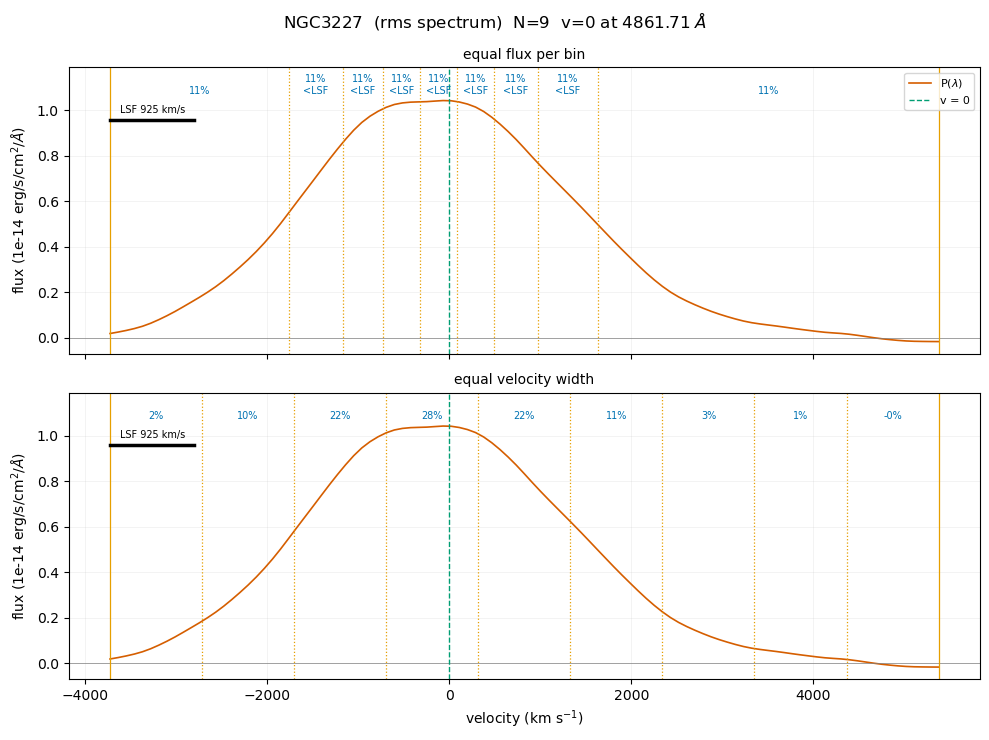

In [5]:
# ---------------- plot: profile + edges, both schemes ----------------
from matplotlib import pyplot as plt

v = wave_to_vel(res['w'], res['lam0'])
fig, axes = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)
fig.suptitle('%s  (%s spectrum)  N=%d  v=0 at %.2f $\\AA$'
             % (OBJ, tag, res['nbins'], res['lam0']))
for ax, scheme, label in ((axes[0], 'eqflux', 'equal flux per bin'),
                          (axes[1], 'eqwidth', 'equal velocity width')):
    r = res[scheme]
    ax.grid(alpha=0.2, linewidth=0.5)
    ax.plot(v, res['pr'], color=C_SUB, lw=1.2, label='P($\\lambda$)')
    ax.axhline(0.0, color='gray', lw=0.5)
    ax.axvline(0.0, color=C_NARROW, lw=1.0, ls='--', label='v = 0')
    for i, ve in enumerate(r['v_edges']):
        ax.axvline(ve, color=C_MODEL, lw=0.9,
                   ls=':' if 0 < i < res['nbins'] else '-')
    top = np.max(res['pr'])
    for i, b in enumerate(r['bins']):
        vc = 0.5 * (r['v_edges'][i] + r['v_edges'][i + 1])
        note = '%.0f%%' % (100.0 * b['frac'])
        if i in r['narrow']:
            note += '\n<LSF'
        ax.text(vc, 1.02 * top, note, ha='center', va='bottom',
                fontsize=7, color=C_BROAD)
    # LSF scale bar
    ax.plot([r['v_edges'][0], r['v_edges'][0] + LSF_KMS],
            [0.92 * top] * 2, color=C_DATA, lw=2.5)
    ax.text(r['v_edges'][0] + 0.5 * LSF_KMS, 0.94 * top,
            'LSF %.0f km/s' % LSF_KMS, ha='center', va='bottom', fontsize=7)
    ax.set_ylim(top=1.14 * top)
    ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
    ax.set_title(label, fontsize=10)
axes[1].set_xlabel('velocity (km s$^{-1}$)')
axes[0].legend(fontsize=8, loc='upper right')
fig.tight_layout()
fig.savefig('%s_velbins_%s.pdf' % (OBJ, tag), format='pdf',
            bbox_inches='tight')
plt.show()